# 탱크 Exchanger / Heat 진단 모델 — 최종 정리

## 구성

| 파일 | 역할 |
|---|---|
| `Tank_Preprocess.py` | 신호 전처리 (스케일 변환, 글리치 제거, 채터링 병합, cool 표시) |
| `Tank_Diagnosis_Model.py` | 진단 규칙 3가지 + `relay_warning` JSON 출력 |
| `전처리_설명.ipynb` | 전처리가 왜/어떻게 돌아가는지 |
| 이 노트북 | 전체 사용법과 실측 검증 결과 |

## 판정 규칙

| 규칙 | 조건 | 보고 대상 |
|---|---|---|
| **① heat 이상** | 전날 PV 최솟값 < `TK_Temp_L_Set` | heater ID |
| **② exchanger/cool 이상** | 사이클이 켜진 뒤 **10분 안에 안 꺼짐** | cool 없으면 exchanger ID / cool 있으면 exchanger + cooler ID |
| **③ 성능 저하** | cool 동반 사이클 **10회 연속** | exchanger ID |

규칙 ② 의 근거: exchanger 는 온도가 SV 밑으로 내려가면 꺼진다. 그래서
**안 꺼졌다 = 온도를 못 잡았다** 와 같은 말이다.

## 출력

```json
{
  "relay_warning": {
    "P00221": {"type": "thermal", "message": "열교환기 냉각 응답 지연 · 설정 온도 복귀 시간 증가 추세"},
    "P00220": {"type": "thermal", "message": "쿨러 냉각 응답 지연 · 열교환기 동시 가동에도 설정 온도 미복귀"}
  }
}
```


## 1. 준비

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 170)

PARKKT = os.getcwd() if os.path.basename(os.getcwd()) == "parkkt" else os.path.join(os.getcwd(), "parkkt")
sys.path.insert(0, PARKKT)

import Tank_Preprocess as prep
import Tank_Diagnosis_Model as model

TANK = "P1"
START, END = "2026-09-09 10:00:00", "now()"

### 릴레이 ID 표

고장 부위별로 보고할 ID. 모델 로직은 이 표만 보고, 태그 이름/ID 를 직접 들고 있지 않다.

In [2]:
display(pd.DataFrame(model.RELAY_IDS))
dups = model.validate_relay_ids()
if dups:
    print("\n⚠️ 위 경고는 받은 ID 표에 중복이 있다는 뜻이다. 그대로 두고 쓰는 중.")

,heater,cooler,exchanger
P1,P00270,P00220,P00221
P2,P00272,P00224,P00225
P3,P00275,P0022A,P0022B
P4,P00274,P00228,P00229
P5,P00277,P0022E,P0022F
I1,P00271,P00222,P00223
I2,P00273,P00226,P00227
I3,P00276,P00231,P00220


⚠️ 릴레이 ID 중복: P00220 <- cooler.P1 / exchanger.I3

⚠️ 위 경고는 받은 ID 표에 중복이 있다는 뜻이다. 그대로 두고 쓰는 중.


### 메시지 문구

`heater` 문구가 기준이고, 나머지는 같은 구조([장치][동작] [증상] · [지표] [추세])로 맞췄다.

In [3]:
for k, v in model.MESSAGES.items():
    print(f"{k:20s} {v}")

heater               히터 가열 응답 지연 · 설정 온도 도달 시간 증가 추세
exchanger            열교환기 냉각 응답 지연 · 설정 온도 복귀 시간 증가 추세
cooler               쿨러 냉각 응답 지연 · 열교환기 동시 가동에도 설정 온도 미복귀
exchanger_degrade    열교환기 냉각 성능 저하 · 쿨러 동시 가동 연속 발생


## 2. 한 줄 사용법

In [4]:
result = model.diagnose(TANK, START, END)
print(model.to_json(result))

{
  "relay_warning": {
    "P00221": {
      "type": "thermal",
      "message": "열교환기 냉각 응답 지연 · 설정 온도 복귀 시간 증가 추세"
    },
    "P00220": {
      "type": "thermal",
      "message": "쿨러 냉각 응답 지연 · 열교환기 동시 가동에도 설정 온도 미복귀"
    }
  }
}


## 3. 자세히 보기

`detail=True` 를 주면 판정 근거가 같이 온다.

In [5]:
result = model.diagnose(TANK, START, END, detail=True)
d = result["_detail"]

print(f"[{d['tank']}] 파라미터 {d['params']}")
print(f"  사이클 수               {d['n_cycles']:,}")
print(f"  ① heat 이상일           {d['heat_abnormal_days']}")
print(f"  ② exchanger 단독        {d['exchanger_only']}")
print(f"  ② exchanger+cool        {d['exchanger_with_cool']}")
print(f"  ③ 성능저하 사이클        {d['degrade_cycles']}  (cool 최대 연속 {d['max_cool_run']})")

[P1] 파라미터 {'MAX_ON_SEC': 600, 'CONSEC_COOL_N': 10}
  사이클 수               1,254
  ① heat 이상일           0
  ② exchanger 단독        3
  ② exchanger+cool        10
  ③ 성능저하 사이클        0  (cool 최대 연속 3)


In [6]:
print("=== ① heat 진단 (일별 최저 PV vs L_Set) ===")
display(d["heat_daily"].round(2))

=== ① heat 진단 (일별 최저 PV vs L_Set) ===


,pv_min,l_set,margin,heat_abnormal
day,,,,
2026-09-09,17.1,10.0,7.1,False
2026-09-10,17.4,10.0,7.4,False
2026-09-11,18.0,10.0,8.0,False
2026-09-12,17.4,10.0,7.4,False
2026-09-13,22.7,10.0,12.7,False
2026-09-14,16.9,10.0,6.9,False
2026-09-15,17.2,10.0,7.2,False
2026-09-16,17.4,10.0,7.4,False
2026-09-17,17.0,10.0,7.0,False


In [7]:
print("=== ② 이상으로 잡힌 사이클 ===")
display(d["abnormal_cycles"])

=== ② 이상으로 잡힌 사이클 ===


,cycle_start,cycle_end,on_duration_sec,cool_overlap,cause
6,2026-09-09 17:24:17.547881,2026-09-09 18:14:14.730361,2997.182480,False,exchanger 이상
147,2026-09-11 14:58:29.104709,2026-09-11 15:09:59.562684,690.457975,False,exchanger 이상
262,2026-09-14 05:32:37.614437,2026-09-14 06:10:05.787521,2248.173084,True,exchanger와 cool 이상
337,2026-09-15 06:13:33.604155,2026-09-15 06:33:53.213197,1219.609042,True,exchanger와 cool 이상
412,2026-09-16 06:15:45.975768,2026-09-16 06:30:16.266275,870.290507,True,exchanger와 cool 이상
485,2026-09-17 06:10:47.908624,2026-09-17 06:37:11.950867,1584.042243,True,exchanger와 cool 이상
559,2026-09-18 06:13:10.067914,2026-09-18 06:38:58.282924,1548.215010,True,exchanger와 cool 이상
631,2026-09-19 06:13:46.500001,2026-09-19 06:31:38.801759,1072.301758,True,exchanger와 cool 이상
706,2026-09-21 05:28:15.345413,2026-09-21 05:54:44.160163,1588.814750,True,exchanger와 cool 이상
934,2026-09-27 11:33:32.838087,2026-09-27 12:36:36.570046,3783.731959,True,exchanger와 cool 이상


## 4. 판정 기준이 적절한지 확인

정상 사이클의 ON 지속시간 분포와 판정 기준(10분)을 겹쳐 본다.

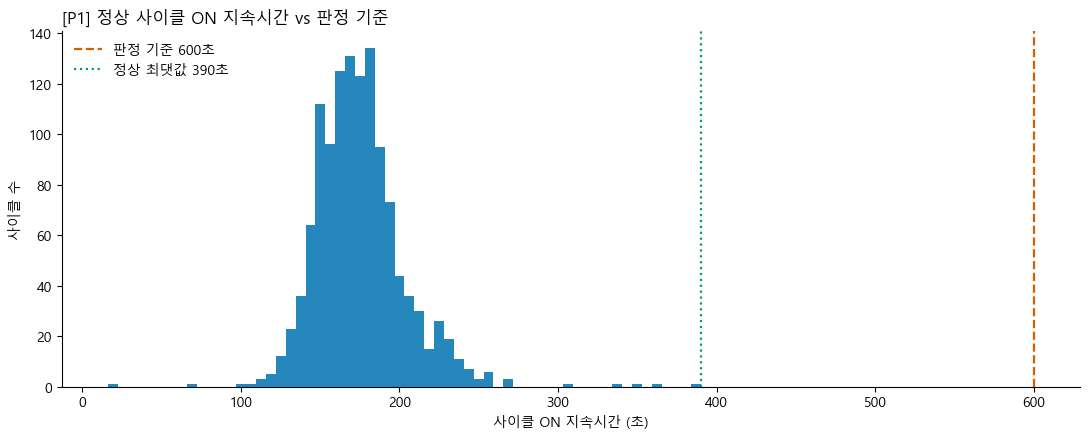

정상 최댓값 390초 / 기준 600초 → 여유 1.5배
99% 지점 255초


In [8]:
data = prep.preprocess(TANK, START, END)
cyc = model.check_cycle_duration(data["cycles"], model.params(TANK)["MAX_ON_SEC"])
ok = cyc[~cyc["abnormal"]]["on_duration_sec"]
thr = model.params(TANK)["MAX_ON_SEC"]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(ok, bins=60, color="#0072B2", alpha=0.85)
ax.axvline(thr, color="#D55E00", linestyle="--", linewidth=1.6, label=f"판정 기준 {thr}초")
ax.axvline(ok.max(), color="#009E73", linestyle=":", linewidth=1.6,
           label=f"정상 최댓값 {ok.max():.0f}초")
ax.set_xlabel("사이클 ON 지속시간 (초)"); ax.set_ylabel("사이클 수")
ax.set_title(f"[{TANK}] 정상 사이클 ON 지속시간 vs 판정 기준", loc="left")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

print(f"정상 최댓값 {ok.max():.0f}초 / 기준 {thr}초 → 여유 {thr/ok.max():.1f}배")
print(f"99% 지점 {ok.quantile(0.99):.0f}초")

## 5. 여러 탱크 한 번에

`relay_warning` 이 하나로 합쳐져서 나온다.

In [9]:
multi = model.diagnose_many(["P1"], START, END)
print(model.to_json(multi))

{
  "relay_warning": {
    "P00221": {
      "type": "thermal",
      "message": "열교환기 냉각 응답 지연 · 설정 온도 복귀 시간 증가 추세"
    },
    "P00220": {
      "type": "thermal",
      "message": "쿨러 냉각 응답 지연 · 열교환기 동시 가동에도 설정 온도 미복귀"
    }
  }
}


## 6. 실시간 판정

사이클이 끝나기를 기다리지 않는다. 켜진 지 10분이 지나는 순간 바로 이상으로 띄운다.
`cycle_end=None` 이면 "아직 켜져 있는 중" 으로 보고 `now` 기준으로 판정한다.

In [10]:
cyc, _ = model.check_consecutive_cool(cyc)

# 정상 사이클
r = cyc[~cyc["abnormal"]].iloc[-1]
print("정상   :", model.judge_cycle(TANK, r["cycle_start"], r["cycle_end"], data["cool"]))

# 이상 사이클 — 끝난 뒤 판정
bad = cyc[cyc["abnormal"]]
if len(bad):
    b = bad.iloc[-1]
    print("이상   :", model.judge_cycle(TANK, b["cycle_start"], b["cycle_end"], data["cool"]))

    # 같은 사이클을 "아직 켜져 있는 중" 으로, 10분 1초 시점에 판정
    t_now = b["cycle_start"] + pd.Timedelta(seconds=model.params(TANK)["MAX_ON_SEC"] + 1)
    live = model.judge_cycle(TANK, b["cycle_start"], None, data["cool"], now=t_now)
    print("실시간 :", live["state"], live["on_sec"], "초")
    print(model.to_json(live))

정상   : {'state': '정상', 'relay_warning': {}, 'on_sec': 142.9, 'cool_overlap': False, 'cool_run': 0}
이상   : {'state': '이상', 'relay_warning': {'P00221': {'type': 'thermal', 'message': '열교환기 냉각 응답 지연 · 설정 온도 복귀 시간 증가 추세'}, 'P00220': {'type': 'thermal', 'message': '쿨러 냉각 응답 지연 · 열교환기 동시 가동에도 설정 온도 미복귀'}}, 'on_sec': 1338.8, 'cool_overlap': True, 'cool_run': 1}
실시간 : 이상 601.0 초
{
  "relay_warning": {
    "P00221": {
      "type": "thermal",
      "message": "열교환기 냉각 응답 지연 · 설정 온도 복귀 시간 증가 추세"
    },
    "P00220": {
      "type": "thermal",
      "message": "쿨러 냉각 응답 지연 · 열교환기 동시 가동에도 설정 온도 미복귀"
    }
  }
}


## 7. 다른 탱크로 확장할 때

**태그 이름과 릴레이 ID 는 설정 표에만 있다.** 진단 함수들은 `pandas.Series` 만 받고
태그 이름을 모른다. 그래서 탱크 추가는 표에 한 줄 넣는 걸로 끝난다.

```python
# Tank_Preprocess.py
_EXCH_COOL["P6"] = ("워킹 Tank ... Exchanger SOL", "워킹 Tank ... Cooling SOL")

# Tank_Diagnosis_Model.py
RELAY_IDS["heater"]["P6"] = "P002xx"
RELAY_IDS["cooler"]["P6"] = "P002xx"
RELAY_IDS["exchanger"]["P6"] = "P002xx"
```

**주의**
- 한글 태그는 탱크마다 공백 개수가 다르다(`워킹 Tank 2-1 SOFT  Heater` 는 스페이스 2개).
  InfluxDB 에 찍힌 그대로 복사해야 한다.
- I2 는 cool/exchanger 가 `Tank 2-2 MDI`, heat/feeding 은 `Tank 2 MDI` 로 이름이 다르다.
- `TK_Temp_PV_I*` 는 I1~I3 만 있다.

**임계값도 탱크별로 다를 수 있다.** 탱크마다 냉각 능력과 사이클 리듬이 달라서,
P1 에서 맞춘 10분 기준이 다른 탱크에도 맞는지는 각 탱크 데이터로 확인해야 한다.
확인 후에는 `TANK_OVERRIDES` 에 넣으면 된다.

```python
TANK_OVERRIDES = {"I2": {"MAX_ON_SEC": 900}}
```


In [11]:
# 탱크별로 기준이 맞는지 확인할 때 쓰는 코드
def check_threshold(tank, start, end):
    data = prep.preprocess(tank, start, end)
    on = data["cycles"]["on_duration_sec"]
    thr = model.params(tank)["MAX_ON_SEC"]
    return {"탱크": tank, "사이클": len(on),
            "ON 중앙값": round(on.median()),
            "ON 99%": round(on.quantile(0.99)),
            "ON 최댓값": round(on.max()),
            "현재 기준": thr,
            "여유(99% 대비)": round(thr / on.quantile(0.99), 1)}


pd.DataFrame([check_threshold("P1", START, END)])

,탱크,사이클,ON 중앙값,ON 99%,ON 최댓값,현재 기준,여유(99% 대비)
0,P1,1254,173,531,3784,600,1.1


## 알아둘 점

실측(P1, 2026-09-09~10-02, 1,254 사이클) 기준으로 지금 설정은 이렇게 동작한다.

**① heat 기준은 사실상 안 울린다.** `TK_Temp_L_Set_P1` 이 10.0℃ 인데 실제 일별 최저
PV 는 16.9~17.5℃ 라 여유가 7℃ 다. 완전 고장 전용 알람에 가깝다. 조기 경보를 원하면
L_Set 대신 과거 일별 최저값 분포 기준으로 바꾸는 게 실효성이 있다.

**③ 10회 연속 기준도 안 울린다.** 실측 최대 연속이 3회(1회 110건, 2회 8건, 3회 2건)라
10회는 역대 최대의 3.3배다. 조기 경보용으로는 5회 정도가 현실적이다.

**② 10분 기준은 적절하다.** 정상 사이클 ON 지속시간 99% 지점이 255초라 여유가 충분하다.

**아침 기동 사이클 주의.** 밤새 멈춰 있다 아침에 처음 켜질 때는 온도가 많이 올라가 있어서
사이클이 14~37분까지 길어진다. 이건 고장이 아니라 정상적인 캐치업이다. 전처리된 데이터에
이 구간이 포함되면 매일 오탐이 뜨므로, 직전 OFF 가 1시간 이상인 사이클은 건너뛰는 로직을
추가하는 게 좋다.
